# DSE4211 Group 18 — Cryptocurrency Bubble Prediction
## End-to-End Rolling-Window Evaluation

**Rolling scheme**: 9-month train → 3-month validation (hyper-parameter tuning) → 3-month test, advancing 3 months per fold.

**Models**: LASSO · XGBoost, each trained as a *per-coin* model and as a single *global* model.

**Class imbalance**:
- LASSO — `class_weight='balanced'` (same as `lasso.ipynb`) + SMOTE applied to the training fold.
- XGBoost — SMOTE applied to the training fold (same as `xgboost.ipynb`).

## 0 · Imports & Setup

In [12]:
import sys, warnings, os
warnings.filterwarnings('ignore')

ROOT = os.path.dirname(os.path.abspath('__file__'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
from datetime import datetime
from dateutil.relativedelta import relativedelta
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

from src.lasso_model   import LassoModel
from src.xgboost_model import XGBoostModel
from src.lstm_model    import (LSTMClassifier, SequenceDataset, create_sequences, create_sequences_multi_coin, LSTMModel)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED = 42

## 1 · Configuration

In [2]:
# --- paths ---
DATA_PATH        = 'data/df_features_with_labels.csv'           # raw features (XGBoost)
DATA_PATH_SCALED = 'data/df_features_with_label_standardised.csv'  # globally standardised (LASSO)

# --- rolling-window sizes (in calendar months) ---
TRAIN_MONTHS = 9
VAL_MONTHS   = 3
TEST_MONTHS  = 3
STEP_MONTHS  = 3   # roll-forward step

# --- target ---
TARGET = 'label_lead'   # integer lead label present in both CSVs

LABEL_NAMES = ['Not Bubble', 'Bubble Creation', 'Bubble Collapse']

# --- coins ---
COINS = ['ADA', 'BNB', 'BTC', 'DOGE', 'ETH', 'SOL']

# --- XGBoost: set tune=True to run RandomizedSearchCV (slow, n_iter=40) ---
XGB_TUNE = False

## 2 · Data Loading & Preprocessing

In [3]:
df_raw    = pd.read_csv(DATA_PATH,        parse_dates=['date'])
df_scaled = pd.read_csv(DATA_PATH_SCALED, parse_dates=['date'])

print(f'Raw shape:    {df_raw.shape}')
print(f'Scaled shape: {df_scaled.shape}')
df_raw.head(3)

Raw shape:    (13359, 136)
Scaled shape: (13359, 137)


,date,open,high,low,close,volume,symbol,buy_bitcoin_trend,crypto_crash_trend,bitcoin_price_trend,...,volume_ratio_30_lag_14,fear_greed_lag_14,rsi_14_lag_14,day_of_week,month,quarter,is_month_start,is_month_end,label,label_lead
0,2018-05-01,0.3414,0.3603,0.3187,0.3550,120368721.7500,ADA,4,0,60,...,0.8693,47.0000,49.4400,1,5,2,1,0,0,0
1,2018-05-02,0.3550,0.3759,0.3450,0.3720,65457686.2900,ADA,4,0,58,...,0.8693,47.0000,49.4400,2,5,2,0,0,0,0
2,2018-05-03,0.3720,0.3885,0.3640,0.3672,88326409.6500,ADA,5,0,59,...,0.8693,47.0000,49.4400,3,5,2,0,0,0,0


In [4]:
# All preprocessing (label encoding, lead target, inf removal) is done in feature_engineering.ipynb.
# df_raw and df_scaled are ready to use as-is.
print(f'Label distribution (raw):\n{df_raw[TARGET].value_counts()}\n')
print(f'Label distribution (scaled):\n{df_scaled[TARGET].value_counts()}')

Label distribution (raw):
label_lead
0    10432
1     2001
2      926
Name: count, dtype: int64

Label distribution (scaled):
label_lead
0    10432
1     2001
2      926
Name: count, dtype: int64


In [5]:
# --- XGBoost feature columns (raw, unstandardised) ---
NON_FEATURE_COLS = {
    'date', 'symbol',
    'gsadf_label_90', 'gsadf_label_95', 'label', 'label_lead',
    'fear_greed_classification',  # ordinal duplicate of extreme_fear/greed/fear/greed dummies
}
FEATURE_COLS = [c for c in df_raw.columns if c not in NON_FEATURE_COLS
                and df_raw[c].dtype != object]

# --- LASSO feature columns (globally standardised) ---
NON_FEATURE_COLS_SCALED = {
    'date', 'symbol', 'label', 'label_lead',
    'gsadf_map_90', 'gsadf_map_95', 'gsadf_map_90_lead', 'gsadf_map_95_lead',
}
FEATURE_COLS_SCALED = [c for c in df_scaled.columns if c not in NON_FEATURE_COLS_SCALED
                       and df_scaled[c].dtype != object]

# --- One-hot coin dummies for global models ---
coin_dummies     = pd.get_dummies(df_raw['symbol'],    prefix='coin').astype(float)
coin_dummies_s   = pd.get_dummies(df_scaled['symbol'], prefix='coin').astype(float)
df_global        = pd.concat([df_raw,    coin_dummies],   axis=1)
df_global_scaled = pd.concat([df_scaled, coin_dummies_s], axis=1)

FEATURE_COLS_GLOBAL        = FEATURE_COLS        + list(coin_dummies.columns)
FEATURE_COLS_SCALED_GLOBAL = FEATURE_COLS_SCALED + list(coin_dummies_s.columns)

print(f'XGBoost features (per-coin):  {len(FEATURE_COLS)}')
print(f'XGBoost features (global):    {len(FEATURE_COLS_GLOBAL)}')
print(f'LASSO   features (per-coin):  {len(FEATURE_COLS_SCALED)}')
print(f'LASSO   features (global):    {len(FEATURE_COLS_SCALED_GLOBAL)}')

XGBoost features (per-coin):  129
XGBoost features (global):    135
LASSO   features (per-coin):  133
LASSO   features (global):    139


## 3 · Rolling-Window Framework

In [6]:
def generate_windows(date_min: pd.Timestamp, date_max: pd.Timestamp):
    """Yield (train_start, val_start, test_start, test_end) tuples."""
    train_start = date_min
    while True:
        val_start  = train_start  + relativedelta(months=TRAIN_MONTHS)
        test_start = val_start    + relativedelta(months=VAL_MONTHS)
        test_end   = test_start   + relativedelta(months=TEST_MONTHS)
        if test_end > date_max:
            break
        yield train_start, val_start, test_start, test_end
        train_start += relativedelta(months=STEP_MONTHS)


def split_df(df: pd.DataFrame, train_start, val_start, test_start, test_end):
    tr = df[(df['date'] >= train_start) & (df['date'] < val_start)]
    va = df[(df['date'] >= val_start)   & (df['date'] < test_start)]
    te = df[(df['date'] >= test_start)  & (df['date'] < test_end)]
    return tr, va, te


# Determine overall date range
DATE_MIN = df_raw['date'].min()
DATE_MAX = df_raw['date'].max()

all_windows = list(generate_windows(DATE_MIN, DATE_MAX))
print(f'Total windows: {len(all_windows)}')
print(f'  First: {all_windows[0][0].date()} → {all_windows[0][3].date()}')
print(f'  Last:  {all_windows[-1][0].date()} → {all_windows[-1][3].date()}')

Total windows: 22
  First: 2018-05-01 → 2019-08-01
  Last:  2023-08-01 → 2024-11-01


## 4 · Utility Functions

In [7]:
def apply_smote(X: np.ndarray, y: np.ndarray,
                k_neighbors: int = 5) -> tuple:
    """SMOTE on training fold only. k is capped when a class has too few
    samples — matches the safety check in xgboost.ipynb apply_smote()."""
    if len(np.unique(y)) < 2:
        return X, y
    counts = np.bincount(y, minlength=3)
    min_count = counts[counts > 0].min()
    k = min(k_neighbors, min_count - 1)
    if k < 1:
        return X, y
    sm = SMOTE(k_neighbors=k, random_state=SEED)
    return sm.fit_resample(X, y)


def record(results: list, model_name: str, scope: str, coin: str,
           fold: int, window: tuple, metrics: dict):
    ts, vs, tes, tee = window
    results.append({
        'model': model_name, 'scope': scope, 'coin': coin, 'fold': fold,
        'train_start': ts.date(), 'test_end': tee.date(),
        **metrics
    })

## 5 · Per-Coin Rolling-Window Experiments

### 5.1 LASSO — per coin

In [8]:
import src.lasso_model as _lm
import importlib
from sklearn.linear_model import LogisticRegressionCV

# Patch fit() to always use ovr
def _patched_fit(self, X_train, y_train, feature_names=None, **kwargs):
    self.feature_names_ = feature_names
    self.model = LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        multi_class="ovr",
        class_weight="balanced",
        cv=self.cv,
        max_iter=self.max_iter,
        random_state=self.random_state,
        n_jobs=-1,
    )
    self.model.fit(X_train, y_train)
    return self

_lm.LassoModel.fit = _patched_fit

In [9]:
results = []

for coin in COINS:
    coin_df = df_scaled[df_scaled['symbol'] == coin].copy()
    coin_windows = list(generate_windows(coin_df['date'].min(),
                                         coin_df['date'].max()))
    print(f'\n{coin}: {len(coin_windows)} windows')

    for fold, window in enumerate(coin_windows):
        tr, va, te = split_df(coin_df, *window)
        if len(tr) < 30 or len(te) < 5:
            continue

        X_tr = np.nan_to_num(tr[FEATURE_COLS_SCALED].values, nan=0.0)
        X_te = np.nan_to_num(te[FEATURE_COLS_SCALED].values, nan=0.0)
        y_tr, y_te = tr[TARGET].values, te[TARGET].values

        if len(np.unique(y_tr)) < 2:
            continue

        X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr)

        m = LassoModel().fit(X_tr_sm, y_tr_sm, feature_names=FEATURE_COLS_SCALED)
        record(results, 'LASSO', 'per_coin', coin, fold, window,
               m.evaluate(X_te, y_te))

print('\n✓ LASSO per-coin complete')


ADA: 22 windows

BNB: 22 windows

BTC: 22 windows

DOGE: 17 windows

ETH: 22 windows

SOL: 13 windows

✓ LASSO per-coin complete


### 5.2 XGBoost — per coin

In [10]:
for coin in COINS:
    coin_df = df_raw[df_raw['symbol'] == coin].copy()
    coin_windows = list(generate_windows(coin_df['date'].min(),
                                         coin_df['date'].max()))
    print(f'\n{coin}: {len(coin_windows)} windows')

    for fold, window in enumerate(coin_windows):
        tr, va, te = split_df(coin_df, *window)
        if len(tr) < 30 or len(te) < 5:
            continue

        X_tr = np.nan_to_num(tr[FEATURE_COLS].values, nan=0.0)
        X_te = np.nan_to_num(te[FEATURE_COLS].values, nan=0.0)
        y_tr, y_te = tr[TARGET].values, te[TARGET].values

        if len(np.unique(y_tr)) < 2:
            continue

        X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr)

        m = XGBoostModel(tune=XGB_TUNE)
        m.fit(X_tr_sm, y_tr_sm)
        record(results, 'XGBoost', 'per_coin', coin, fold, window,
               m.evaluate(X_te, y_te))

print('\n✓ XGBoost per-coin complete')


ADA: 22 windows

BNB: 22 windows

BTC: 22 windows

DOGE: 17 windows

ETH: 22 windows

SOL: 13 windows

✓ XGBoost per-coin complete


### 5.3 LSTM — per coin

Uses the same 42-feature `MANUAL_FEATURES` set as `lstm.ipynb`.

In [ ]:
# for coin in COINS:
#     coin_df = df_raw[df_raw['symbol'] == coin].copy()
#     coin_windows = list(generate_windows(coin_df['date'].min(),
#                                          coin_df['date'].max()))
#     print(f'\n{coin}: {len(coin_windows)} windows')

#     for fold, window in enumerate(coin_windows):
#         tr, va, te = split_df(coin_df, *window)
#         if len(tr) < LSTM_LOOKBACK + 10 or len(te) < LSTM_LOOKBACK + 5:
#             continue

#         X_tr_s, X_va_s, X_te_s = scale_fold(
#             tr[LSTM_FEATURES].values,
#             va[LSTM_FEATURES].values,
#             te[LSTM_FEATURES].values,
#         )
#         y_tr, y_te = tr[TARGET].values, te[TARGET].values

#         if len(np.unique(y_tr)) < 2:
#             continue

#         X_tr_seq, y_tr_seq = create_sequences(X_tr_s, y_tr, LSTM_LOOKBACK)
#         X_va_seq, y_va_seq = create_sequences(X_va_s, va[TARGET].values, LSTM_LOOKBACK)
#         X_te_seq, y_te_seq = create_sequences(X_te_s, y_te, LSTM_LOOKBACK)

#         if len(X_tr_seq) == 0 or len(X_te_seq) == 0:
#             continue

#         m = LSTMModel(
#             input_size=len(LSTM_FEATURES),
#             hidden_size=LSTM_HIDDEN_SIZE,
#             num_layers=LSTM_NUM_LAYERS,
#             dropout=LSTM_DROPOUT,
#             dense_size=LSTM_DENSE_SIZE,
#             lookback=LSTM_LOOKBACK,
#             epochs=LSTM_EPOCHS,
#             patience=LSTM_PATIENCE,
#             batch_size=LSTM_BATCH_SIZE,
#             lr=LSTM_LR,
#             weight_decay=LSTM_WEIGHT_DECAY,
#         )
#         m.fit(X_tr_seq, y_tr_seq, X_val_seq=X_va_seq, y_val_seq=y_va_seq)
#         record(results, 'LSTM', 'per_coin', coin, fold, window,
#                m.evaluate(X_te_seq, y_te_seq))

# print('\n✓ LSTM per-coin complete')


ADA: 22 windows


NameError: name 'LSTM_LOOKBACK' is not defined

## 6 · Global Model Rolling-Window Experiments

One model trained on **all coins simultaneously** per fold.
Coin identity is encoded as one-hot features appended to the feature matrix.

### 6.1 LASSO — global

In [ ]:
global_windows = list(generate_windows(
    df_scaled['date'].min(), df_scaled['date'].max()
))
print(f'Global windows: {len(global_windows)}')

for fold, window in enumerate(global_windows):
    tr, va, te = split_df(df_global_scaled, *window)
    if len(tr) < 30 or len(te) < 5:
        continue

    X_tr = np.nan_to_num(tr[FEATURE_COLS_SCALED_GLOBAL].values, nan=0.0)
    X_te = np.nan_to_num(te[FEATURE_COLS_SCALED_GLOBAL].values, nan=0.0)
    y_tr, y_te = tr[TARGET].values, te[TARGET].values

    if len(np.unique(y_tr)) < 2:
        continue

    X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr)

    m = LassoModel().fit(X_tr_sm, y_tr_sm, feature_names=FEATURE_COLS_SCALED_GLOBAL)
    record(results, 'LASSO', 'global', 'ALL', fold, window,
           m.evaluate(X_te, y_te))

print('\n✓ LASSO global complete')

Global windows: 22

✓ LASSO global complete


### 6.2 XGBoost — global

In [ ]:
for fold, window in enumerate(global_windows):
    tr, va, te = split_df(df_global, *window)
    if len(tr) < 30 or len(te) < 5:
        continue

    X_tr = np.nan_to_num(tr[FEATURE_COLS_GLOBAL].values, nan=0.0)
    X_te = np.nan_to_num(te[FEATURE_COLS_GLOBAL].values, nan=0.0)
    y_tr, y_te = tr[TARGET].values, te[TARGET].values

    if len(np.unique(y_tr)) < 2:
        continue

    X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr)

    m = XGBoostModel(tune=XGB_TUNE)
    m.fit(X_tr_sm, y_tr_sm)
    record(results, 'XGBoost', 'global', 'ALL', fold, window,
           m.evaluate(X_te, y_te))

print('\n✓ XGBoost global complete')


✓ XGBoost global complete


### 6.3 LSTM — global

Sequences are built per-coin within each fold to avoid crossing coin boundaries,
then concatenated for a single global model.

In [ ]:
for fold, window in enumerate(global_windows):
    tr, va, te = split_df(df_global, *window)
    if len(tr) < LSTM_LOOKBACK + 10 or len(te) < LSTM_LOOKBACK + 5:
        continue

    tr_X_blocks, tr_y_blocks = [], []
    va_X_blocks, va_y_blocks = [], []
    te_X_blocks, te_y_blocks = [], []

    for coin in COINS:
        c_tr = tr[tr['symbol'] == coin]
        c_va = va[va['symbol'] == coin]
        c_te = te[te['symbol'] == coin]
        if len(c_tr) < LSTM_LOOKBACK + 5:
            continue
        tr_X_blocks.append(c_tr[LSTM_FEATURES_GLOBAL].values)
        tr_y_blocks.append(c_tr[TARGET].values)
        va_X_blocks.append(c_va[LSTM_FEATURES_GLOBAL].values)
        va_y_blocks.append(c_va[TARGET].values)
        te_X_blocks.append(c_te[LSTM_FEATURES_GLOBAL].values)
        te_y_blocks.append(c_te[TARGET].values)

    if not tr_X_blocks:
        continue

    if len(np.unique(np.concatenate(tr_y_blocks))) < 2:
        continue

    # Fit scaler on all training coins combined, transform each block separately
    scaler = StandardScaler()
    scaler.fit(np.nan_to_num(np.vstack(tr_X_blocks), nan=0.0))
    scale_b = lambda blocks: [
        scaler.transform(np.nan_to_num(b, nan=0.0)) for b in blocks
    ]

    X_tr_seq, y_tr_seq = create_sequences_multi_coin(
        scale_b(tr_X_blocks), tr_y_blocks, LSTM_LOOKBACK)
    X_va_seq, y_va_seq = create_sequences_multi_coin(
        scale_b(va_X_blocks), va_y_blocks, LSTM_LOOKBACK)
    X_te_seq, y_te_seq = create_sequences_multi_coin(
        scale_b(te_X_blocks), te_y_blocks, LSTM_LOOKBACK)

    if len(X_tr_seq) == 0 or len(X_te_seq) == 0:
        continue

    m = LSTMModel(
        input_size=len(LSTM_FEATURES_GLOBAL),
        hidden_size=LSTM_HIDDEN_SIZE,
        num_layers=LSTM_NUM_LAYERS,
        dropout=LSTM_DROPOUT,
        dense_size=LSTM_DENSE_SIZE,
        lookback=LSTM_LOOKBACK,
        epochs=LSTM_EPOCHS,
        patience=LSTM_PATIENCE,
        batch_size=LSTM_BATCH_SIZE,
        lr=LSTM_LR,
        weight_decay=LSTM_WEIGHT_DECAY,
    )
    m.fit(X_tr_seq, y_tr_seq, X_val_seq=X_va_seq, y_val_seq=y_va_seq)
    record(results, 'LSTM', 'global', 'ALL', fold, window,
           m.evaluate(X_te_seq, y_te_seq))

print('\n✓ LSTM global complete')

## 7 · Results & Comparison

In [ ]:
df_res = pd.DataFrame(results)
print(f'Total result rows: {len(df_res)}')
df_res.head()

Total result rows: 210


,model,scope,coin,fold,train_start,test_end,accuracy,macro_f1,weighted_f1,f1_not_bubble,f1_creation,f1_collapse
0,LASSO,per_coin,ADA,5,2019-08-01,2020-11-01,0.9022,0.8676,0.9088,0.9353,0.8000,0.0000
1,LASSO,per_coin,ADA,6,2019-11-01,2021-02-01,0.3478,0.3083,0.2471,0.1429,0.4737,0.0000
2,LASSO,per_coin,ADA,7,2020-02-01,2021-05-01,0.4719,0.2240,0.5889,0.0000,0.6720,0.0000
3,LASSO,per_coin,ADA,8,2020-05-01,2021-08-01,0.3804,0.2102,0.2605,0.0000,0.6306,0.0000
4,LASSO,per_coin,ADA,9,2020-08-01,2021-11-01,0.7500,0.4950,0.7400,0.0000,0.8000,0.6849


### 7.1 Aggregate summary (mean ± std across folds)

In [ ]:
METRIC_COLS = ['macro_f1', 'weighted_f1', 'accuracy',
               'f1_not_bubble', 'f1_creation', 'f1_collapse']

summary = (
    df_res
    .groupby(['model', 'scope'])[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
print('=== Overall summary (mean ± std across all folds & coins) ===')
summary

=== Overall summary (mean ± std across all folds & coins) ===


macro_f1        weighted_f1        accuracy         \
                     mean    std        mean    std     mean    std   
model   scope                                                         
LASSO   global     0.3998 0.2013      0.6388 0.2714   0.6346 0.2448   
        per_coin   0.3952 0.2843      0.6304 0.3212   0.6038 0.3190   
XGBoost global     0.4343 0.2296      0.6610 0.2917   0.6700 0.2881   
        per_coin   0.4918 0.3573      0.6281 0.3691   0.6400 0.3616   

                 f1_not_bubble        f1_creation        f1_collapse         
                          mean    std        mean    std        mean    std  
model   scope                                                                
LASSO   global          0.6476 0.3045      0.2522 0.3357      0.1162 0.2200  
        per_coin        0.5780 0.3964      0.1684 0.2892      0.0827 0.1948  
XGBoost global          0.7151 0.2860      0.1672 0.2512      0.1052 0.1798  
        per_coin        0.5544 0.4502      0.1862 0.3148      0.0742 0.1944

In [ ]:
summary_mean = (
    df_res
    .groupby(['model', 'scope'])[METRIC_COLS]
    .mean()
    .round(4)
    .sort_values('macro_f1', ascending=False)
    .reset_index()
)
print('=== Ranked by mean macro F1 ===')
summary_mean

=== Ranked by mean macro F1 ===


,model,scope,macro_f1,weighted_f1,accuracy,f1_not_bubble,f1_creation,f1_collapse
0,XGBoost,per_coin,0.4918,0.6281,0.6400,0.5544,0.1862,0.0742
1,XGBoost,global,0.4343,0.6610,0.6700,0.7151,0.1672,0.1052
2,LASSO,global,0.3998,0.6388,0.6346,0.6476,0.2522,0.1162
3,LASSO,per_coin,0.3952,0.6304,0.6038,0.5780,0.1684,0.0827


In [ ]:
per_coin_summary = (
    df_res[df_res['scope'] == 'per_coin']
    .groupby(['coin', 'model'])[METRIC_COLS]
    .mean()
    .round(4)
    .reset_index()
    .sort_values(['coin', 'macro_f1'], ascending=[True, False])
)
print('=== Per-coin mean metrics ===')
per_coin_summary

=== Per-coin mean metrics ===


,coin,model,macro_f1,weighted_f1,accuracy,f1_not_bubble,f1_creation,f1_collapse
1,ADA,XGBoost,0.5686,0.6170,0.6359,0.4923,0.2066,0.1007
0,ADA,LASSO,0.3949,0.6440,0.6376,0.5137,0.2412,0.0973
3,BNB,XGBoost,0.3647,0.5849,0.5912,0.5186,0.1550,0.0664
2,BNB,LASSO,0.3111,0.4999,0.4749,0.4553,0.1300,0.0595
5,BTC,XGBoost,0.6557,0.7857,0.7959,0.7323,0.2171,0.0511
4,BTC,LASSO,0.4613,0.7742,0.7386,0.7977,0.1396,0.0548
7,DOGE,XGBoost,0.4983,0.6374,0.6507,0.6405,0.1066,0.0074
6,DOGE,LASSO,0.3094,0.6283,0.5807,0.6263,0.0579,0.0572
8,ETH,LASSO,0.5460,0.6597,0.6388,0.5025,0.3297,0.0876
9,ETH,XGBoost,0.5321,0.6376,0.6413,0.4502,0.3296,0.1007


### 7.2 Visualisations

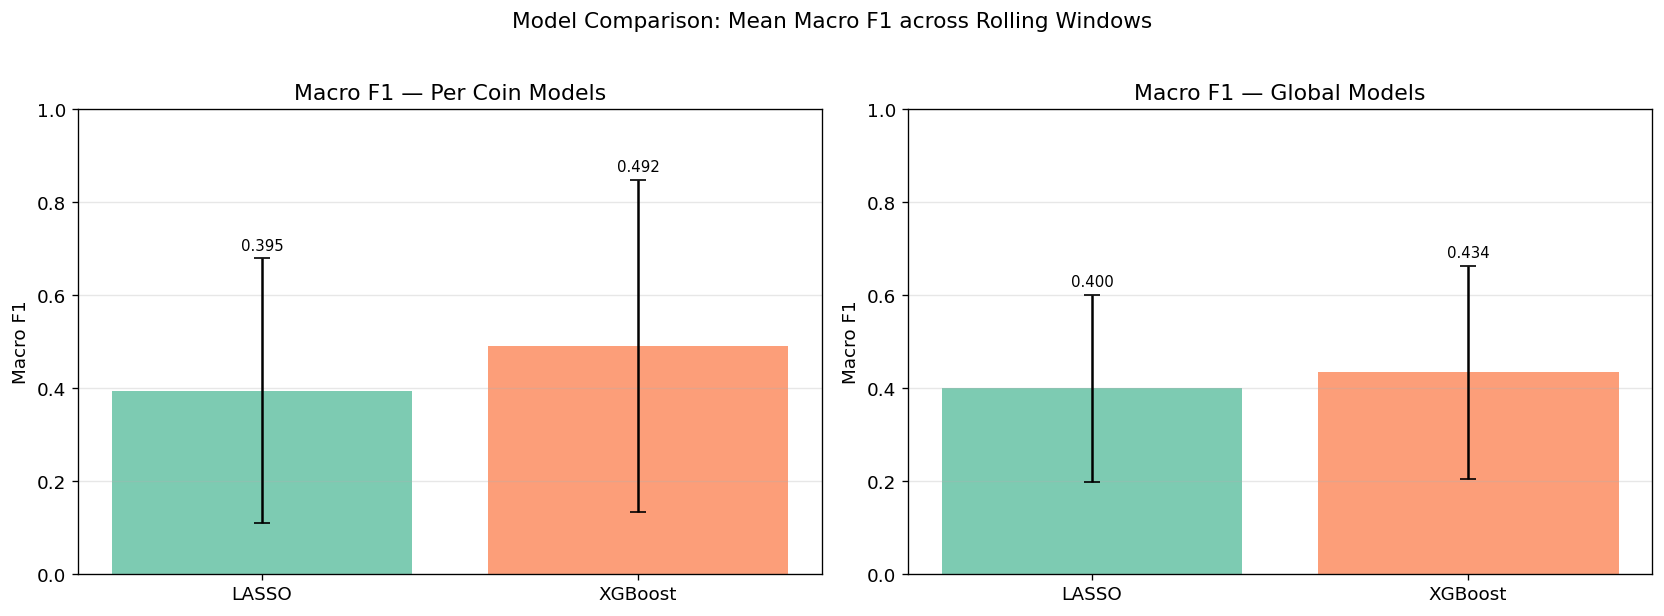

In [ ]:
os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scope in zip(axes, ['per_coin', 'global']):
    sub = df_res[df_res['scope'] == scope]
    grp = sub.groupby('model')['macro_f1'].agg(['mean', 'std']).reset_index()
    colors = sns.color_palette('Set2', len(grp))
    bars = ax.bar(grp['model'], grp['mean'], yerr=grp['std'],
                  color=colors, capsize=5, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(f'Macro F1 — {scope.replace("_", " ").title()} Models')
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison: Mean Macro F1 across Rolling Windows', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/macro_f1_comparison.png', bbox_inches='tight')
plt.show()

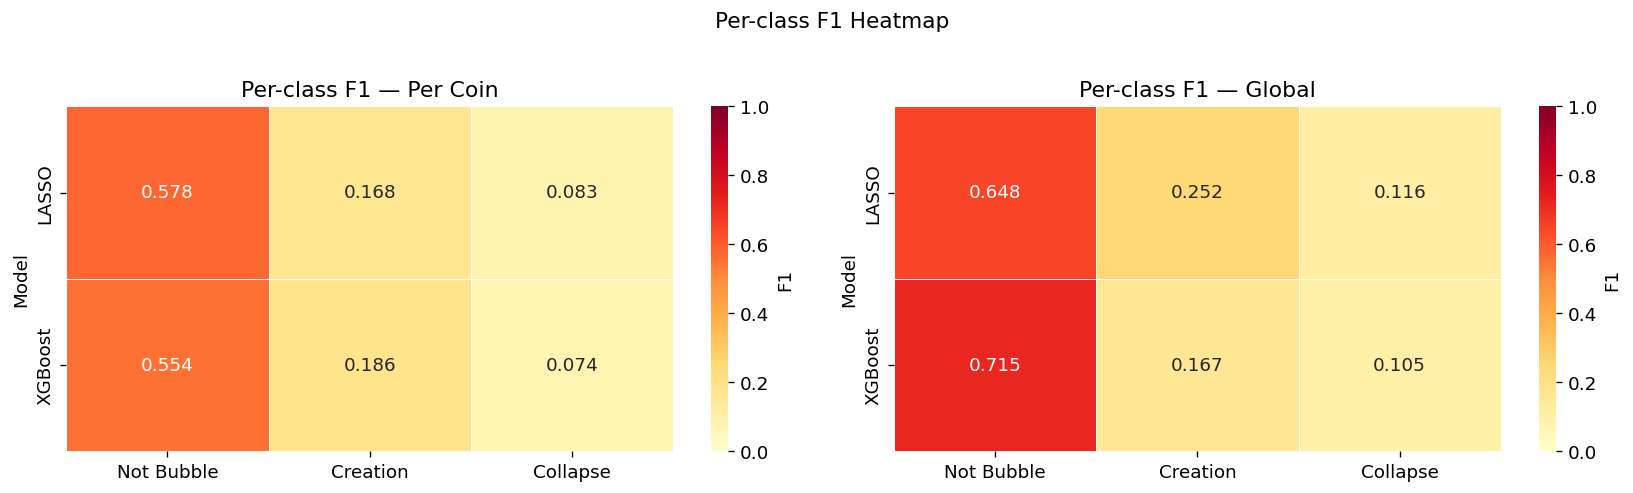

In [ ]:
class_metrics = ['f1_not_bubble', 'f1_creation', 'f1_collapse']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, scope in zip(axes, ['per_coin', 'global']):
    sub = df_res[df_res['scope'] == scope]
    pivot = (
        sub.groupby('model')[class_metrics].mean()
           .rename(columns={'f1_not_bubble': 'Not Bubble',
                            'f1_creation':   'Creation',
                            'f1_collapse':   'Collapse'})
    )
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.3f',
                cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={'label': 'F1'})
    ax.set_title(f'Per-class F1 — {scope.replace("_", " ").title()}')
    ax.set_ylabel('Model')

plt.suptitle('Per-class F1 Heatmap', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/per_class_f1_heatmap.png', bbox_inches='tight')
plt.show()

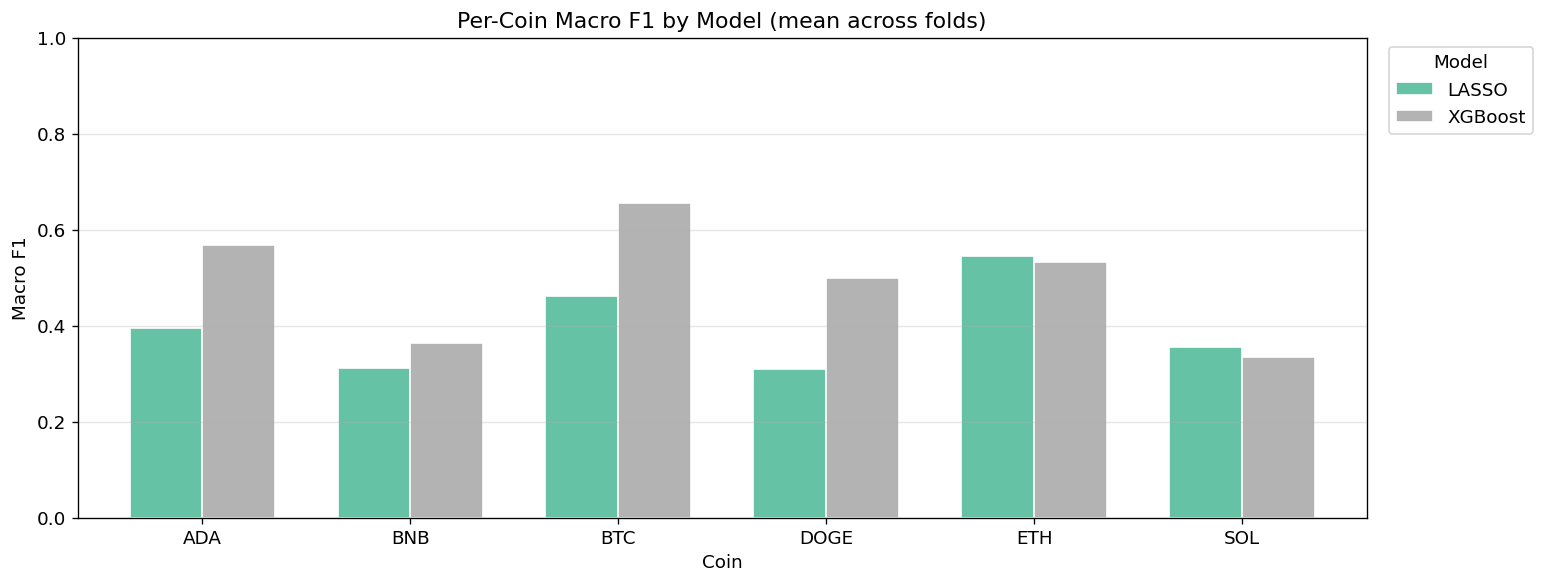

In [ ]:
per_coin_df = df_res[df_res['scope'] == 'per_coin']
pivot_coin  = (
    per_coin_df.groupby(['coin', 'model'])['macro_f1']
               .mean().unstack('model')
)
ax = pivot_coin.plot(kind='bar', figsize=(13, 5), colormap='Set2',
                     edgecolor='white', width=0.7)
ax.set_title('Per-Coin Macro F1 by Model (mean across folds)')
ax.set_ylabel('Macro F1')
ax.set_xlabel('Coin')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/per_coin_macro_f1.png', bbox_inches='tight')
plt.show()

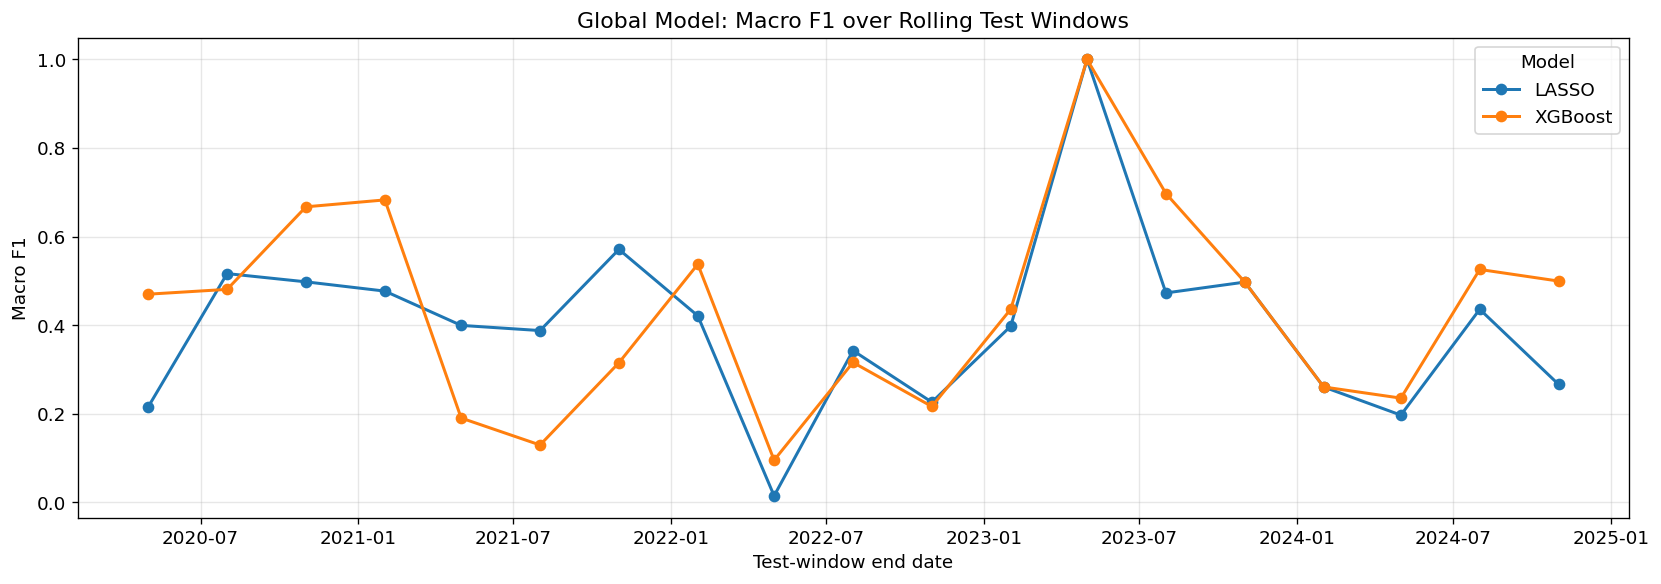

In [ ]:
global_df = df_res[df_res['scope'] == 'global'].copy()
global_df['test_end'] = pd.to_datetime(global_df['test_end'])

fig, ax = plt.subplots(figsize=(14, 5))
for model, grp in global_df.groupby('model'):
    grp = grp.sort_values('test_end')
    ax.plot(grp['test_end'], grp['macro_f1'], marker='o', label=model, linewidth=1.8)
ax.set_title('Global Model: Macro F1 over Rolling Test Windows')
ax.set_ylabel('Macro F1')
ax.set_xlabel('Test-window end date')
ax.legend(title='Model')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/global_macro_f1_over_time.png', bbox_inches='tight')
plt.show()

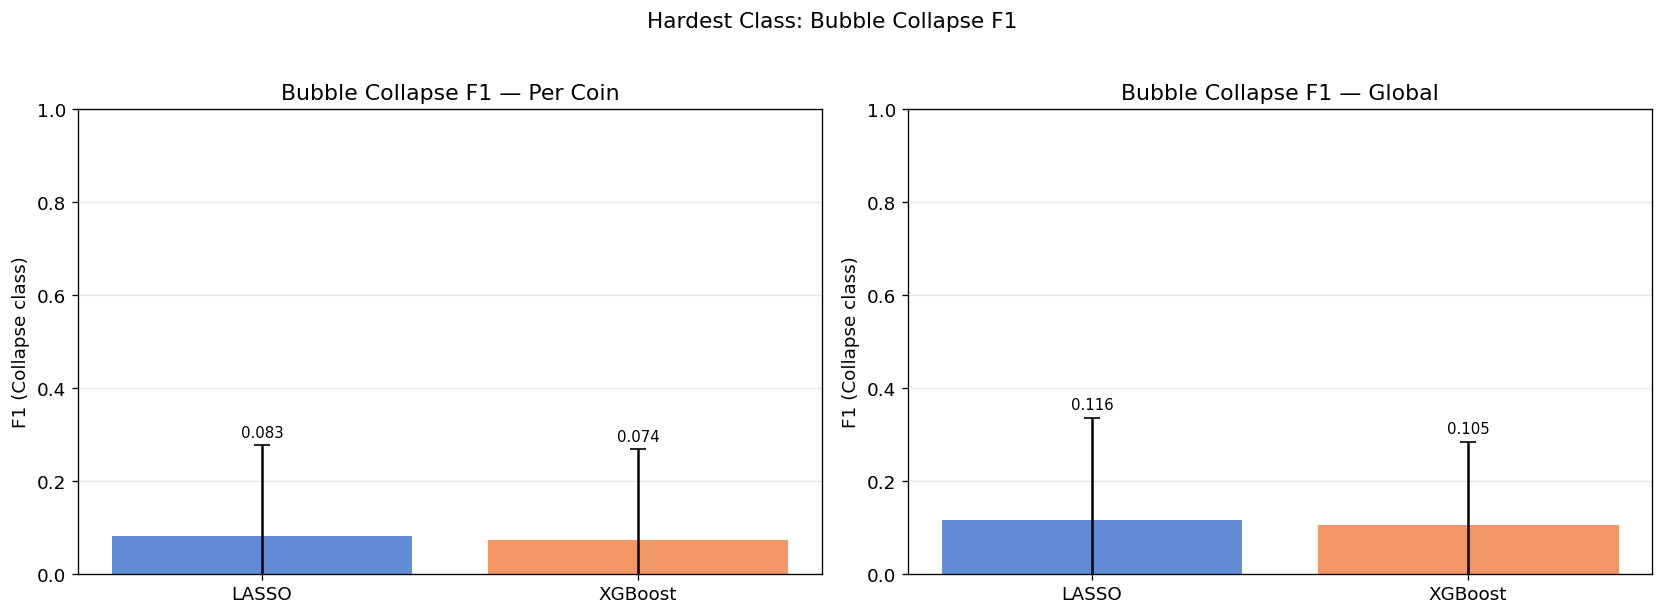

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scope in zip(axes, ['per_coin', 'global']):
    sub = df_res[df_res['scope'] == scope]
    grp = sub.groupby('model')['f1_collapse'].agg(['mean', 'std']).reset_index()
    colors = sns.color_palette('muted', len(grp))
    bars = ax.bar(grp['model'], grp['mean'], yerr=grp['std'],
                  color=colors, capsize=5, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(f'Bubble Collapse F1 — {scope.replace("_", " ").title()}')
    ax.set_ylabel('F1 (Collapse class)')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Hardest Class: Bubble Collapse F1', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/collapse_f1_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
df_res.to_csv('outputs/rolling_window_results.csv', index=False)
summary_mean.to_csv('outputs/model_summary.csv', index=False)
per_coin_summary.to_csv('outputs/per_coin_summary.csv', index=False)
print('Results saved to outputs/')

Results saved to outputs/


## 8 · Per-Coin vs Global Comparison

In [ ]:
scope_compare = (
    df_res[df_res['scope'] == 'per_coin']
    .groupby('model')['macro_f1'].mean().rename('per_coin').to_frame()
    .join(
        df_res[df_res['scope'] == 'global']
        .groupby('model')['macro_f1'].mean().rename('global')
    )
)
scope_compare['delta (per-global)'] = scope_compare['per_coin'] - scope_compare['global']
print('=== Per-coin vs Global Macro F1 ===')
scope_compare.round(4)

=== Per-coin vs Global Macro F1 ===


,per_coin,global,delta (per-global)
model,,,
LASSO,0.3952,0.3998,-0.0046
XGBoost,0.4918,0.4343,0.0575


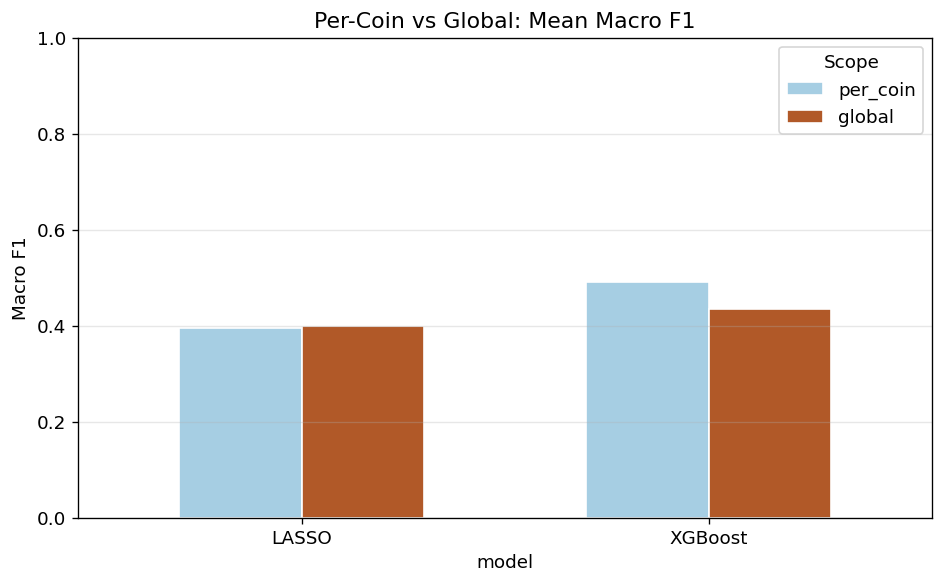

In [ ]:
ax = scope_compare[['per_coin', 'global']].plot(
    kind='bar', figsize=(8, 5), colormap='Paired',
    edgecolor='white', width=0.6
)
ax.set_title('Per-Coin vs Global: Mean Macro F1')
ax.set_ylabel('Macro F1')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1)
ax.legend(title='Scope')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/per_coin_vs_global.png', bbox_inches='tight')
plt.show()